# Tema 1. Ejercicio 2. Regresión lineal penalizada: Ridge, Lasso y Elastic Net

**Técnicas Avanzadas de Predicción en Negocios**

Datos: Encuesta Cuatrienal de Estructura Salarial 2022 (INE), microdatos anonimizados.

## Qué vamos a hacer

Este cuaderno continúa el anterior (*Introducción a Python para predicción*). Allí ajustamos una regresión lineal por mínimos cuadrados para predecir el salario anual. Aquí vamos a modificar ese modelo de una forma que a primera vista parece extraña: le vamos a **impedir que ajuste demasiado bien los datos de entrenamiento**, penalizando el tamaño de sus coeficientes. Veremos con datos reales por qué eso puede mejorar las predicciones sobre datos nuevos, cuándo lo hace y cuándo no.

Las tres variantes que estudiaremos son la regresión **Ridge**, el **Lasso** y su combinación, **Elastic Net**. Las tres están en `scikit-learn` y encajan en el `Pipeline` del cuaderno anterior cambiando una sola línea.

Si conocéis `glmnet` de R, este cuaderno es su equivalente en Python. Al final hay una tabla de correspondencias, con un aviso importante sobre los nombres de los parámetros.

## Objetivos

Al terminar deberías ser capaz de:

1. Explicar qué es el sobreajuste y reconocerlo comparando el error en entrenamiento y en prueba.
2. Escribir la función de pérdida de Ridge y de Lasso y explicar qué hace el parámetro de penalización.
3. Ajustar `Ridge`, `Lasso` y `ElasticNet` dentro de un `Pipeline` y leer sus coeficientes.
4. Interpretar el camino de los coeficientes al variar la penalización, y la diferencia entre encoger (Ridge) y anular (Lasso).
5. Elegir la penalización por validación cruzada con `RidgeCV`, `LassoCV` y `ElasticNetCV`, sin usar el conjunto de prueba.

## Cómo trabajar con el cuaderno

Igual que en el anterior: ejecuta las celdas en orden, lee las celdas de texto marcadas como **Lectura** después de cada resultado y resuelve los bloques **Ejercicio** en el momento, con lo visto hasta ese punto. Tiempo estimado: unas dos horas.

## 0. Preparación: lo que ya hicimos en el cuaderno anterior

Repetimos, condensados en pocas celdas, los pasos del cuaderno de introducción: cargar los datos, limpiar la respuesta, fijar los roles de las variables y partir en entrenamiento y prueba. No hay nada nuevo hasta la sección 1; si algo no te resulta familiar, vuelve al cuaderno anterior.

Las únicas novedades en los `import` son los modelos penalizados: `Ridge`, `Lasso`, `ElasticNet` y sus versiones con validación cruzada `RidgeCV`, `LassoCV`, `ElasticNetCV`. Todos están en `sklearn.linear_model`, el mismo módulo que `LinearRegression`.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # oculta avisos que no afectan a los resultados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sns.set_theme(style="whitegrid")
SEMILLA = 42
AZUL, NARANJA, GRIS = "#2a78d6", "#e5701a", "#898781"
print("Librerías cargadas")

Librerías cargadas


In [2]:
URL_DATOS = "https://juandmontoro.github.io/tap/data/EES_2022.tab"

df = pd.read_csv(URL_DATOS, sep="\t", low_memory=False)
df.columns = [c.replace('"', "").strip() for c in df.columns]   # algunos nombres vienen entre comillas

# Misma limpieza y misma muestra que en el cuaderno anterior
tope = df["RETRINOIN"].quantile(0.99)
limpio = df[(df["RETRINOIN"] > 0) & (df["RETRINOIN"] <= tope)]
datos = limpio.sample(n=40_000, random_state=SEMILLA).reset_index(drop=True)
print("Muestra de trabajo:", datos.shape)

Muestra de trabajo: (40000, 56)


Los roles de las variables son los mismos: la respuesta es el salario bruto anual `RETRINOIN`, quedan fuera los componentes del salario (fuga de información), los identificadores y el peso muestral, y usamos como predictores las 14 categóricas y las 2 numéricas del cuaderno anterior.

In [3]:
RESPUESTA = "RETRINOIN"
FUGA_SALARIAL = ["SALBASE", "COMSAL", "COMSALTT", "EXTRAORM", "PHEXTRA", "BASE", "GEXTRA",
                 "VESPNOIN", "VESPIN", "RETRIIN", "IRPFMES", "COTIZA"]

PRED_CATEGORICOS = ["SEXO", "ESTU", "ANOS2", "TIPOCON", "TIPOJOR", "CNO1", "CNACE", "CONTROL",
                    "MERCADO", "REGULACION", "RESPONSA", "NUTS1", "TIPOPAIS", "ESTRATO2"]
PRED_NUMERICOS = ["ANOANTI", "JAP"]
PREDICTORES = PRED_CATEGORICOS + PRED_NUMERICOS

X = datos[PREDICTORES].copy()
y = datos[RESPUESTA]
for col in PRED_CATEGORICOS:
    X[col] = X[col].astype("category")
assert not set(FUGA_SALARIAL) & set(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, "  Prueba:", X_test.shape)

Entrenamiento: (30000, 16)   Prueba: (10000, 16)


### 0.1 Dos funciones auxiliares

En este cuaderno vamos a ajustar muchos modelos, así que conviene escribir dos funciones que repitan el trabajo por nosotros. En Python una función se define con `def`, igual que con `function()` en R; lo que devuelve se indica con `return`.

- `crear_preprocesador()` devuelve un `ColumnTransformer` **nuevo** cada vez que se llama. Es importante que sea nuevo: un `Pipeline` ajusta sus pasos "en sitio", y si dos `Pipeline` compartieran el mismo objeto, el segundo ajuste pisaría al primero.
- `evaluar()` ajusta un `Pipeline` sobre unos datos de entrenamiento y devuelve, en un diccionario, el R² en entrenamiento y en prueba, el RMSE y el MAE en prueba, y cuántos coeficientes son distintos de cero. Ese último número será importante con Lasso.

Un **diccionario** (`dict`) es una colección de pares clave-valor, como una `list` con nombres en R: `{"R2_test": 0.58, "RMSE": 11707}`.

In [4]:
def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            ("numericas", StandardScaler(), PRED_NUMERICOS),
            ("categoricas", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False),
             PRED_CATEGORICOS),
        ],
        remainder="drop",
    )

def evaluar(modelo, X_entrena, y_entrena, X_prueba=None, y_prueba=None):
    # Ajusta el Pipeline `modelo` en (X_entrena, y_entrena) y lo evalúa en prueba
    if X_prueba is None:                       # por defecto, el conjunto de prueba global
        X_prueba, y_prueba = X_test, y_test
    modelo.fit(X_entrena, y_entrena)
    pred_entrena = modelo.predict(X_entrena)
    pred_prueba = modelo.predict(X_prueba)
    coef = modelo.named_steps["modelo"].coef_
    return {
        "R2_train": round(r2_score(y_entrena, pred_entrena), 3),
        "R2_test": round(r2_score(y_prueba, pred_prueba), 3),
        "RMSE_test": round(root_mean_squared_error(y_prueba, pred_prueba)),
        "MAE_test": round(mean_absolute_error(y_prueba, pred_prueba)),
        "coef_no_nulos": int((np.abs(coef) > 1e-8).sum()),
        "coef_total": len(coef),
    }

print("Funciones definidas")

Funciones definidas


## 1. Punto de partida: la regresión lineal

Volvemos a ajustar el modelo del cuaderno anterior, ahora con las funciones auxiliares. Fíjate en que el último paso del `Pipeline` se llama `"modelo"`; ese nombre es el que usa `evaluar()` para extraer los coeficientes.

In [5]:
ols = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", LinearRegression())])
resultado_ols = evaluar(ols, X_train, y_train)
resultado_ols

{'R2_train': 0.577,
 'R2_test': 0.58,
 'RMSE_test': 11707,
 'MAE_test': 8277,
 'coef_no_nulos': 88,
 'coef_total': 88}

**Lectura.** Los números coinciden con los del cuaderno anterior (R² en prueba de 0,58). El R² en entrenamiento es prácticamente igual al de prueba: el modelo no está sobreajustando. Tenemos 30 000 filas de entrenamiento para estimar 88 coeficientes (las 2 numéricas más las 86 columnas indicadoras que crea el `OneHotEncoder`), y con esa proporción los mínimos cuadrados funcionan bien.

Guarda esta idea: **la penalización va a ser útil cuando esa proporción sea desfavorable**. Vamos a provocar esa situación.

## 2. Por qué penalizar los coeficientes

En clase hemos visto que los estimadores de mínimos cuadrados son insesgados, pero su **varianza** puede ser grande cuando los predictores están correlacionados entre sí o cuando el número de predictores es grande en relación con el número de observaciones. Una varianza grande significa que, si repitiéramos la muestra, los coeficientes cambiarían mucho de una a otra; el modelo se está adaptando al ruido de la muestra concreta que tiene delante. A eso se le llama **sobreajuste**, y se reconoce porque el error en entrenamiento es mucho menor que el error en datos nuevos.

La **regularización** (o penalización) consiste en modificar la función de pérdida para que, además del error de predicción, penalice el tamaño de los coeficientes. El resultado es un modelo con coeficientes **encogidos hacia cero**: algo sesgado, pero con menos varianza. Si la reducción de varianza compensa el sesgo introducido, las predicciones sobre datos nuevos mejoran. Esa es la apuesta.

Dos avisos antes de empezar:

- **Nombres.** En las transparencias el parámetro de penalización se llama $\lambda$. En `scikit-learn` se llama `alpha`. Es el mismo concepto.
- **Escala.** La penalización depende de las unidades de cada predictor: si una variable se mide en miles en lugar de en unidades, su coeficiente se hace mil veces más pequeño y la penalización lo trata de forma distinta. Por eso los predictores numéricos **deben estandarizarse**. Nuestro `Pipeline` ya lo hace con `StandardScaler`; las columnas indicadoras (0/1) se dejan tal cual, que es la práctica habitual.

### 2.1 Un experimento: pocos datos y muchas columnas

Para ver el problema, tomamos una muestra de solo **200 trabajadores** del conjunto de entrenamiento y ajustamos con ella los mínimos cuadrados. El conjunto de prueba sigue siendo el mismo (10 000 filas), de modo que las comparaciones con la sección 1 son justas.

`sample()` sobre `X_train` elige 200 filas al azar; `y_train.loc[...]` recupera las respuestas de esas mismas filas usando su índice (en R sería `y_train[rownames(X_pocos)]`).

In [6]:
X_pocos = X_train.sample(n=200, random_state=SEMILLA)
y_pocos = y_train.loc[X_pocos.index]

ols_pocos = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", LinearRegression())])
resultado_ols_pocos = evaluar(ols_pocos, X_pocos, y_pocos)
resultado_ols_pocos

{'R2_train': 0.752,
 'R2_test': 0.214,
 'RMSE_test': 16012,
 'MAE_test': 12236,
 'coef_no_nulos': 87,
 'coef_total': 87}

**Lectura.** Con 200 observaciones para 87 coeficientes, el R² en entrenamiento sube hasta 0,75 (mejor que con 30 000 filas) mientras que el R² en prueba se hunde hasta 0,21. El modelo ha memorizado la muestra pequeña y generaliza mal. Este es el sobreajuste del que hablan las transparencias, y el escenario en el que la penalización debería ayudar. Lo usaremos como banco de pruebas en las secciones 3 a 6.

(Que sean 87 columnas y no 88 se debe a que `min_frequency=0.01` agrupa de forma distinta las categorías infrecuentes cuando la muestra es pequeña.)

## 3. Regresión Ridge

La regresión Ridge (regularización L2) sustituye la función de pérdida de mínimos cuadrados, $RSS = \sum_i (y_i - \hat{y}_i)^2$, por

$$RSS + \lambda \sum_{j=1}^{k} \beta_j^2, \qquad \lambda \geq 0.$$

El segundo término crece con el cuadrado de los coeficientes, así que el mínimo se alcanza en coeficientes más pequeños que los de mínimos cuadrados. Cuanto mayor es $\lambda$, más se encogen; con $\lambda = 0$ recuperamos la regresión lineal. La constante $\beta_0$ no se penaliza.

En `scikit-learn`, `Ridge(alpha=...)`. Probemos con `alpha=10` sobre la muestra pequeña.

In [7]:
ridge_pocos = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", Ridge(alpha=10))])
resultado_ridge_pocos = evaluar(ridge_pocos, X_pocos, y_pocos)

pd.DataFrame({"Lineal": resultado_ols_pocos, "Ridge (alpha=10)": resultado_ridge_pocos})

,Lineal,Ridge (alpha=10)
R2_train,0.752,0.684
R2_test,0.214,0.464
RMSE_test,16012.000,13229.000
MAE_test,12236.000,9667.000
coef_no_nulos,87.000,87.000
coef_total,87.000,87.000


**Lectura.** Con la misma muestra de 200 filas, Ridge pierde ajuste en entrenamiento (de 0,75 a 0,68) y gana mucho en prueba (de 0,21 a 0,46). Ha aceptado un poco de sesgo a cambio de reducir la varianza, y el saldo es claramente positivo. Todos los coeficientes siguen siendo distintos de cero: Ridge encoge, no elimina.

### 3.1 El camino de los coeficientes

Hemos probado un solo valor de `alpha`. Para entender qué hace la penalización conviene recorrer muchos valores y observar cómo cambian los coeficientes y los errores. El bucle siguiente ajusta Ridge para 30 valores de `alpha` espaciados en escala logarítmica (`np.logspace(-2, 5, 30)` va de $10^{-2}$ a $10^{5}$) y guarda los coeficientes y los R² de cada ajuste.

En Python, un bucle `for` recorre una secuencia; dentro, `append()` añade elementos a una lista. Al terminar convertimos las listas en `DataFrame` para poder dibujarlas.

In [8]:
alphas_ridge = np.logspace(-2, 5, 30)
coefs, r2_train, r2_test = [], [], []

for a in alphas_ridge:
    modelo = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", Ridge(alpha=a))])
    res = evaluar(modelo, X_pocos, y_pocos)
    coefs.append(modelo.named_steps["modelo"].coef_)
    r2_train.append(res["R2_train"])
    r2_test.append(res["R2_test"])

nombres = modelo.named_steps["preprocesado"].get_feature_names_out()
camino_ridge = pd.DataFrame(coefs, index=alphas_ridge, columns=nombres)
curva_ridge = pd.DataFrame({"R2_train": r2_train, "R2_test": r2_test}, index=alphas_ridge)

print("Mejor alpha en prueba:", round(curva_ridge["R2_test"].idxmax(), 2),
      " R2_test:", curva_ridge["R2_test"].max())

Mejor alpha en prueba: 23.95  R2_test: 0.481


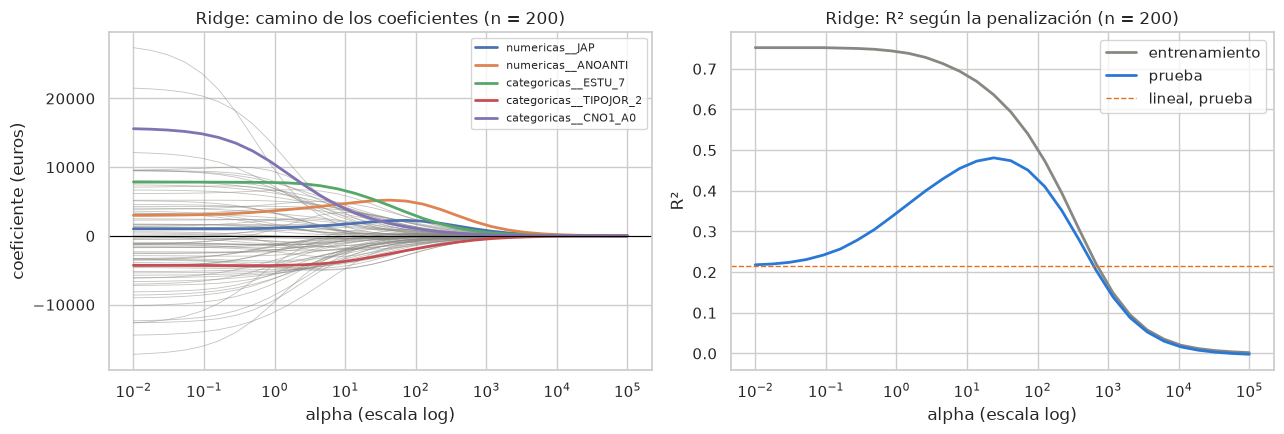

In [9]:
DESTACADAS = ["numericas__JAP", "numericas__ANOANTI", "categoricas__ESTU_7",
              "categoricas__TIPOJOR_2", "categoricas__CNO1_A0"]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: un trazo por coeficiente; los destacados, en color
for col in camino_ridge.columns:
    ejes[0].plot(camino_ridge.index, camino_ridge[col], color=GRIS, lw=0.6, alpha=0.5)
for col, color in zip(DESTACADAS, sns.color_palette("deep", len(DESTACADAS))):
    ejes[0].plot(camino_ridge.index, camino_ridge[col], color=color, lw=2, label=col)
ejes[0].set_xscale("log")
ejes[0].axhline(0, color="black", lw=0.8)
ejes[0].set_xlabel("alpha (escala log)")
ejes[0].set_ylabel("coeficiente (euros)")
ejes[0].set_title("Ridge: camino de los coeficientes (n = 200)")
ejes[0].legend(fontsize=8)

# Derecha: R² en entrenamiento y en prueba
ejes[1].plot(curva_ridge.index, curva_ridge["R2_train"], color=GRIS, lw=2, label="entrenamiento")
ejes[1].plot(curva_ridge.index, curva_ridge["R2_test"], color=AZUL, lw=2, label="prueba")
ejes[1].axhline(resultado_ols_pocos["R2_test"], color=NARANJA, ls="--", lw=1, label="lineal, prueba")
ejes[1].set_xscale("log")
ejes[1].set_xlabel("alpha (escala log)")
ejes[1].set_ylabel("R²")
ejes[1].set_title("Ridge: R² según la penalización (n = 200)")
ejes[1].legend()
plt.tight_layout()
plt.show()

**Lectura.** A la izquierda, cada línea es un coeficiente. Con `alpha` pequeño coinciden con los de mínimos cuadrados; a medida que `alpha` crece se encogen suavemente hacia cero, sin llegar a anularse. No todos lo hacen de forma monótona: `ANOANTI`, por ejemplo, sube antes de bajar, porque va recogiendo el efecto de columnas correlacionadas con ella que se encogen antes. A la derecha, el R² en entrenamiento baja de forma monótona (cuanto más penalizamos, peor ajustamos la muestra), pero el R² en prueba **sube primero y baja después**, con un máximo alrededor de `alpha` = 25. Ese máximo es el equilibrio entre sesgo y varianza: a su izquierda el modelo tiene demasiada varianza, a su derecha demasiado sesgo. La línea naranja discontinua marca la regresión lineal sin penalizar.

### 3.2 La varianza de los coeficientes, vista

La justificación de Ridge es que **reduce la varianza de los estimadores**. Podemos comprobarlo de forma directa: extraemos 30 muestras distintas de 200 trabajadores, ajustamos en cada una la regresión lineal y Ridge, y miramos cuánto varían los coeficientes de una muestra a otra.

In [10]:
COLUMNAS = ["numericas__JAP", "numericas__ANOANTI", "categoricas__SEXO_6",
            "categoricas__ESTU_7", "categoricas__TIPOJOR_2"]
registros = []

for semilla in range(30):
    X_s = X_train.sample(n=200, random_state=semilla)
    y_s = y_train.loc[X_s.index]
    for nombre, estimador in [("Lineal", LinearRegression()), ("Ridge (alpha=30)", Ridge(alpha=30))]:
        modelo = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", estimador)]).fit(X_s, y_s)
        serie = pd.Series(modelo.named_steps["modelo"].coef_,
                          index=modelo.named_steps["preprocesado"].get_feature_names_out())
        for col in COLUMNAS:
            registros.append({"modelo": nombre, "coeficiente": col, "valor": serie.get(col, np.nan)})

variabilidad = pd.DataFrame(registros)
variabilidad.groupby(["coeficiente", "modelo"])["valor"].agg(["mean", "std"]).round(0)

mean     std
coeficiente            modelo                          
categoricas__ESTU_7    Lineal            9118.0  4132.0
                       Ridge (alpha=30)  5876.0  1390.0
categoricas__SEXO_6    Lineal           -1849.0  1653.0
                       Ridge (alpha=30) -1424.0   754.0
categoricas__TIPOJOR_2 Lineal           -3187.0  1611.0
                       Ridge (alpha=30) -2469.0   406.0
numericas__ANOANTI     Lineal            3344.0  1403.0
                       Ridge (alpha=30)  3995.0   887.0
numericas__JAP         Lineal            2013.0  1201.0
                       Ridge (alpha=30)  2605.0   520.0

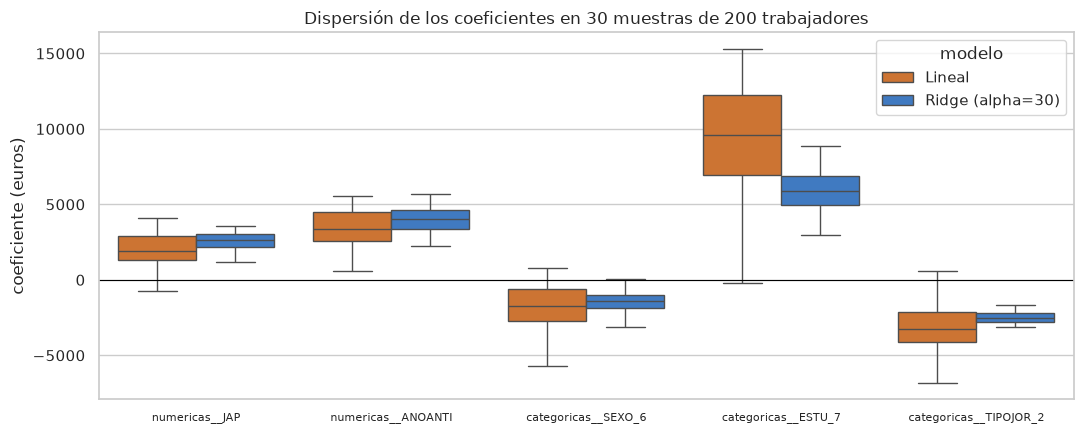

In [11]:
fig, eje = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=variabilidad, x="coeficiente", y="valor", hue="modelo", ax=eje,
            palette=[NARANJA, AZUL], showfliers=False)
eje.axhline(0, color="black", lw=0.8)
eje.set_xlabel("")
eje.set_ylabel("coeficiente (euros)")
eje.set_title("Dispersión de los coeficientes en 30 muestras de 200 trabajadores")
eje.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

**Lectura.** Para cada coeficiente, la desviación típica entre muestras (columna `std`) es entre 1,6 y 4 veces menor con Ridge que con mínimos cuadrados: las cajas azules son mucho más estrechas que las naranjas. A cambio, las medias cambian (sesgo): en la mayoría de los coeficientes se acercan a cero, aunque no en todos, porque al encoger unos coeficientes otros correlacionados con ellos recogen parte del efecto. Es el intercambio sesgo-varianza que describen las transparencias, medido con datos.

### Ejercicio 1. Ridge con muchos datos

Repite el recorrido de la sección 3.1 (bucle sobre `alphas_ridge`, R² en entrenamiento y en prueba) usando **todo** el conjunto de entrenamiento (`X_train`, `y_train`) en lugar de `X_pocos`. Basta con el gráfico de la derecha; no hace falta guardar los coeficientes.

1. ¿Para qué valores de `alpha` el R² en prueba es igual al de la regresión lineal? ¿Cuánto se gana en el mejor caso?
2. ¿A partir de qué `alpha` empieza a empeorar? Compara ese umbral con el de la muestra de 200.
3. Explica en un comentario, con la idea de sesgo y varianza, por qué la penalización ayuda mucho con 200 filas y casi nada con 30 000.

In [12]:
# Escribe aquí tu solución

## 4. Lasso

El Lasso (*Least Absolute Shrinkage and Selection Operator*, regularización L1) penaliza la suma de los **valores absolutos** de los coeficientes:

$$RSS + \lambda \sum_{j=1}^{k} |\beta_j|, \qquad \lambda \geq 0.$$

El cambio parece menor, pero tiene una consecuencia importante: para $\lambda$ suficientemente grande, el Lasso hace que algunos coeficientes sean **exactamente cero**. Es decir, además de encoger, **selecciona variables**: las que quedan con coeficiente cero desaparecen del modelo. Ridge nunca hace eso.

En `scikit-learn`, `Lasso(alpha=...)`. El algoritmo que lo resuelve es iterativo, así que a veces necesita más iteraciones de las que trae por defecto; `max_iter=20_000` evita avisos de falta de convergencia sin efecto apreciable en el tiempo de cálculo. Probemos con `alpha=200` en la muestra pequeña.

In [13]:
lasso_pocos = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", Lasso(alpha=200, max_iter=20_000))])
resultado_lasso_pocos = evaluar(lasso_pocos, X_pocos, y_pocos)

pd.DataFrame({"Lineal": resultado_ols_pocos,
              "Ridge (alpha=10)": resultado_ridge_pocos,
              "Lasso (alpha=200)": resultado_lasso_pocos})

,Lineal,Ridge (alpha=10),Lasso (alpha=200)
R2_train,0.752,0.684,0.651
R2_test,0.214,0.464,0.453
RMSE_test,16012.000,13229.000,13366.000
MAE_test,12236.000,9667.000,9785.000
coef_no_nulos,87.000,87.000,36.000
coef_total,87.000,87.000,87.000


**Lectura.** El Lasso obtiene en prueba un R² parecido al de Ridge, pero lo hace con **muchos menos coeficientes**: la fila `coef_no_nulos` muestra que ha anulado más de la mitad de las 87 columnas. Es un modelo más simple y, con estos datos, igual de bueno.

Veamos qué columnas han sobrevivido. Emparejamos los coeficientes con los nombres de columna del preprocesador y nos quedamos con los distintos de cero, ordenados por valor absoluto. Usamos el mismo umbral que `evaluar()` (valor absoluto mayor que $10^{-8}$) porque el algoritmo iterativo deja a veces valores del orden de $10^{-10}$ que son cero a efectos prácticos.

In [14]:
coef_lasso = pd.Series(lasso_pocos.named_steps["modelo"].coef_,
                       index=lasso_pocos.named_steps["preprocesado"].get_feature_names_out())
supervivientes = coef_lasso[coef_lasso.abs() > 1e-8]

print(f"Columnas con coeficiente distinto de cero: {len(supervivientes)} de {len(coef_lasso)}\n")
print(supervivientes.reindex(supervivientes.abs().sort_values(ascending=False).index).round(0).to_string())

Columnas con coeficiente distinto de cero: 36 de 87

categoricas__ESTU_7          10293.0
categoricas__RESPONSA_0      -9781.0
categoricas__TIPOJOR_1        8478.0
categoricas__ESTU_6           7016.0
categoricas__REGULACION_3     6856.0
categoricas__ANOS2_6          5670.0
categoricas__CNACE_J0        -5359.0
categoricas__CNO1_D0          5144.0
categoricas__NUTS1_4         -4960.0
categoricas__ESTRATO2_3       4952.0
numericas__ANOANTI            4526.0
categoricas__REGULACION_2    -4025.0
categoricas__CNACE_O0         3946.0
categoricas__CNO1_B0          3863.0
categoricas__NUTS1_2          3746.0
categoricas__CNACE_N0        -3354.0
categoricas__ESTU_3          -3194.0
categoricas__REGULACION_1    -2960.0
categoricas__CNO1_C0          2783.0
categoricas__SEXO_1           2633.0
categoricas__CNACE_Q0         2191.0
categoricas__MERCADO_2        2139.0
categoricas__CNO1_N0         -2053.0
numericas__JAP                1697.0
categoricas__CNO1_P0         -1688.0
categoricas__CNO1_A0  

### 4.1 El camino de los coeficientes en Lasso

Repetimos el recorrido de la sección 3.1, ahora con Lasso y con una rejilla de `alpha` entre $10^0$ y $10^4$ (la escala útil es distinta de la de Ridge: además de penalizar $|\beta|$ en lugar de $\beta^2$, `scikit-learn` divide el error cuadrático entre $2n$ en `Lasso` y no en `Ridge`, así que un mismo valor de `alpha` no significa lo mismo en los dos estimadores y no conviene compararlos). Además del R², guardamos cuántos coeficientes quedan distintos de cero.

In [15]:
alphas_lasso = np.logspace(0, 4, 30)
coefs, r2_train, r2_test, no_nulos = [], [], [], []

for a in alphas_lasso:
    modelo = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", Lasso(alpha=a, max_iter=20_000))])
    res = evaluar(modelo, X_pocos, y_pocos)
    coefs.append(modelo.named_steps["modelo"].coef_)
    r2_train.append(res["R2_train"])
    r2_test.append(res["R2_test"])
    no_nulos.append(res["coef_no_nulos"])

camino_lasso = pd.DataFrame(coefs, index=alphas_lasso, columns=nombres)
curva_lasso = pd.DataFrame({"R2_train": r2_train, "R2_test": r2_test, "coef_no_nulos": no_nulos},
                           index=alphas_lasso)

print("Mejor alpha en prueba:", round(curva_lasso["R2_test"].idxmax(), 1),
      " R2_test:", curva_lasso["R2_test"].max(),
      " coeficientes no nulos:", curva_lasso.loc[curva_lasso["R2_test"].idxmax(), "coef_no_nulos"])

Mejor alpha en prueba: 417.5  R2_test: 0.468  coeficientes no nulos: 20


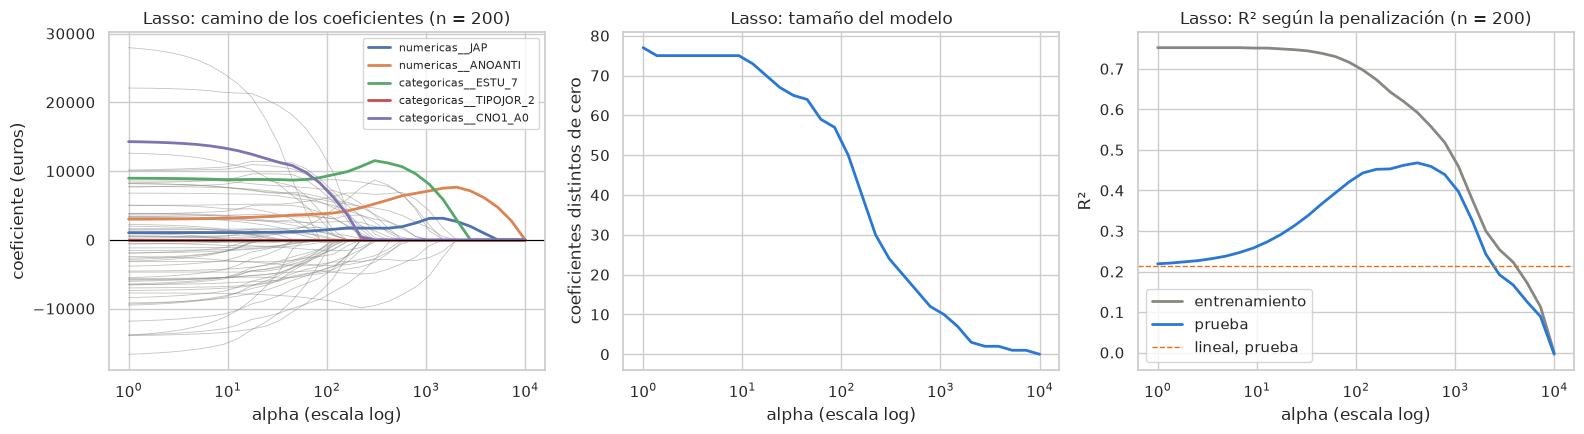

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.5))

for col in camino_lasso.columns:
    ejes[0].plot(camino_lasso.index, camino_lasso[col], color=GRIS, lw=0.6, alpha=0.5)
for col, color in zip(DESTACADAS, sns.color_palette("deep", len(DESTACADAS))):
    ejes[0].plot(camino_lasso.index, camino_lasso[col], color=color, lw=2, label=col)
ejes[0].set_xscale("log")
ejes[0].axhline(0, color="black", lw=0.8)
ejes[0].set_xlabel("alpha (escala log)")
ejes[0].set_ylabel("coeficiente (euros)")
ejes[0].set_title("Lasso: camino de los coeficientes (n = 200)")
ejes[0].legend(fontsize=8)

ejes[1].plot(curva_lasso.index, curva_lasso["coef_no_nulos"], color=AZUL, lw=2)
ejes[1].set_xscale("log")
ejes[1].set_xlabel("alpha (escala log)")
ejes[1].set_ylabel("coeficientes distintos de cero")
ejes[1].set_title("Lasso: tamaño del modelo")

ejes[2].plot(curva_lasso.index, curva_lasso["R2_train"], color=GRIS, lw=2, label="entrenamiento")
ejes[2].plot(curva_lasso.index, curva_lasso["R2_test"], color=AZUL, lw=2, label="prueba")
ejes[2].axhline(resultado_ols_pocos["R2_test"], color=NARANJA, ls="--", lw=1, label="lineal, prueba")
ejes[2].set_xscale("log")
ejes[2].set_xlabel("alpha (escala log)")
ejes[2].set_ylabel("R²")
ejes[2].set_title("Lasso: R² según la penalización (n = 200)")
ejes[2].legend()
plt.tight_layout()
plt.show()

**Lectura.** Compara el primer panel con el de Ridge: aquí las líneas no se acercan a cero de forma suave, sino que **llegan a cero y se quedan ahí** (y, como en Ridge, algunas suben temporalmente mientras otras correlacionadas desaparecen). El panel central lo cuantifica: el número de columnas activas baja de 87 a 0 conforme crece `alpha`. El tercer panel tiene la misma forma que en Ridge, con el máximo en prueba alrededor de `alpha` = 400, donde el modelo conserva unas 20 columnas. Con `alpha` = 10 000 no queda ninguna: el modelo predice la media del salario y su R² es cero.

### Ejercicio 2. Qué variables sobreviven

Ajusta un Lasso con `alpha=1000` sobre la muestra pequeña (`X_pocos`, `y_pocos`) y:

1. Lista las columnas con coeficiente distinto de cero, ordenadas por valor absoluto (como en la celda que sigue a la tabla de la sección 4).
2. Agrupa esas columnas por la variable original de la que proceden. Pista: los nombres tienen la forma `categoricas__CNO1_A0`; con `.str.split("__").str[1]` y luego `.str.split("_").str[0]` se recupera `CNO1`.
3. ¿Qué variables originales han desaparecido por completo del modelo? ¿Te parece razonable a la vista de lo que sabes sobre los salarios?
4. Ajusta sobre la misma muestra de 200 filas la regresión lineal con solo `ESTU`, `ANOANTI` y `TIPOJOR` (el modelo del ejercicio 3 del cuaderno anterior) y compara su R² en prueba con el del Lasso con `alpha=1000` y con `alpha=400`. ¿Qué diferencia hay entre elegir las variables nosotros y dejar que las elija el Lasso?

In [17]:
# Escribe aquí tu solución

## 5. Elegir la penalización sin mirar el conjunto de prueba

Hasta ahora hemos elegido `alpha` mirando el R² **en prueba**. Eso es trampa: el conjunto de prueba está reservado para evaluar el modelo final una sola vez, y si lo usamos para tomar decisiones sobre el modelo, la evaluación deja de ser honesta (es otra forma de fuga de información, como las de las secciones 3 y 4 del cuaderno anterior).

La forma correcta se llama **validación cruzada** y se estudia con detalle en el tema 2. La idea, en dos líneas: se divide el conjunto de **entrenamiento** en $K$ trozos; para cada valor de `alpha` se ajusta el modelo $K$ veces, cada vez dejando un trozo fuera y midiendo el error en él; se elige el `alpha` con menor error medio. El conjunto de prueba no interviene.

`scikit-learn` incorpora esta búsqueda en tres estimadores que se usan como los anteriores:

- `RidgeCV(alphas=...)`: recibe la rejilla de valores. Por defecto usa una forma eficiente de validación cruzada que deja fuera una observación cada vez.
- `LassoCV(cv=5)`: construye su propia rejilla de 100 valores de `alpha` (a partir de los datos) y usa 5 trozos.
- `ElasticNetCV(...)`: lo veremos en la sección 6.

Tras el ajuste, el `alpha` elegido queda en el atributo `alpha_` (con guion bajo final, como todo lo que `scikit-learn` aprende de los datos).

In [18]:
ridge_cv = Pipeline([("preprocesado", crear_preprocesador()),
                     ("modelo", RidgeCV(alphas=np.logspace(-2, 5, 30)))])
resultado_ridge_cv = evaluar(ridge_cv, X_pocos, y_pocos)
print("Ridge: alpha elegido por validación cruzada =", round(ridge_cv.named_steps["modelo"].alpha_, 1))

lasso_cv = Pipeline([("preprocesado", crear_preprocesador()),
                     ("modelo", LassoCV(cv=5, random_state=SEMILLA, max_iter=20_000))])
resultado_lasso_cv = evaluar(lasso_cv, X_pocos, y_pocos)
print("Lasso: alpha elegido por validación cruzada =", round(lasso_cv.named_steps["modelo"].alpha_, 1))

pd.DataFrame({"Lineal": resultado_ols_pocos, "RidgeCV": resultado_ridge_cv, "LassoCV": resultado_lasso_cv})

Ridge: alpha elegido por validación cruzada = 13.7
Lasso: alpha elegido por validación cruzada = 266.5


,Lineal,RidgeCV,LassoCV
R2_train,0.752,0.669,0.629
R2_test,0.214,0.473,0.459
RMSE_test,16012.000,13109.000,13291.000
MAE_test,12236.000,9511.000,9641.000
coef_no_nulos,87.000,87.000,27.000
coef_total,87.000,87.000,87.000


**Lectura.** Sin haber mirado el conjunto de prueba, la validación cruzada ha elegido `alpha` cerca de 14 para Ridge y cerca de 270 para Lasso, valores muy próximos a los máximos que vimos en las curvas de las secciones 3.1 y 4.1. Los R² en prueba (0,47 y 0,46) son casi los mejores alcanzables. Esa es la garantía que buscábamos: elegir bien la penalización con información que sí tendríamos en la práctica.

`LassoCV` guarda el error de validación de cada `alpha` en `mse_path_` (una matriz con una columna por trozo). Su media es la **curva de validación**, y podemos dibujarla para ver qué ha visto el algoritmo.

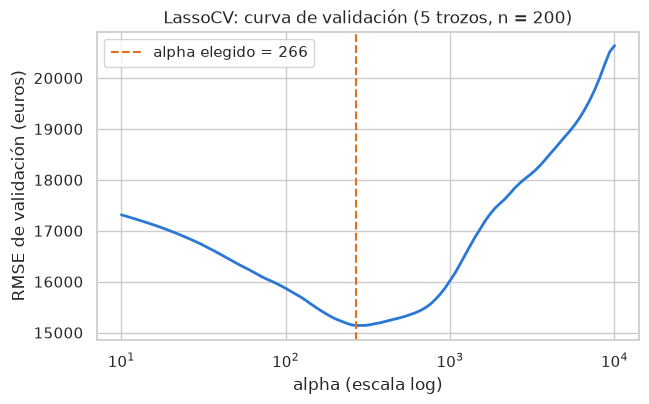

In [19]:
modelo_lcv = lasso_cv.named_steps["modelo"]
error_medio = modelo_lcv.mse_path_.mean(axis=1)

fig, eje = plt.subplots(figsize=(7, 4))
eje.plot(modelo_lcv.alphas_, np.sqrt(error_medio), color=AZUL, lw=2)
eje.axvline(modelo_lcv.alpha_, color=NARANJA, ls="--", label=f"alpha elegido = {modelo_lcv.alpha_:.0f}")
eje.set_xscale("log")
eje.set_xlabel("alpha (escala log)")
eje.set_ylabel("RMSE de validación (euros)")
eje.set_title("LassoCV: curva de validación (5 trozos, n = 200)")
eje.legend()
plt.show()

Un detalle que resolveremos en el tema 2: al poner `LassoCV` dentro del `Pipeline`, el preprocesador se ajusta una vez con las 200 filas y la validación cruzada se hace después, sobre las columnas ya transformadas. Para escalado y codificación *one-hot* la diferencia es despreciable, pero la forma completamente limpia es validar el `Pipeline` entero con `GridSearchCV`, que veremos entonces.

## 6. Elastic Net

Elastic Net combina las dos penalizaciones en una sola función de pérdida. Con la notación de las transparencias,

$$RSS + \lambda \left( \alpha \sum_{j=1}^{k} |\beta_j| + \frac{1-\alpha}{2} \sum_{j=1}^{k} \beta_j^2 \right),$$

donde $\lambda$ controla la cantidad total de penalización y $\alpha \in [0, 1]$ la mezcla: $\alpha = 1$ es Lasso puro, $\alpha = 0$ es Ridge puro y los valores intermedios seleccionan variables (como Lasso) pero repartiendo el peso entre predictores correlacionados (como Ridge).

**Atención a los nombres**, porque aquí hay una fuente clásica de confusión:

| Concepto | Transparencias y `glmnet` (R) | `scikit-learn` |
|---|---|---|
| Cantidad de penalización | $\lambda$ (`lambda`) | `alpha` |
| Mezcla Lasso / Ridge | $\alpha$ (`alpha`) | `l1_ratio` |

Es decir, el `alpha` de `scikit-learn` es el $\lambda$ de R, y la mezcla se llama `l1_ratio`. `ElasticNet(alpha=..., l1_ratio=...)` tiene por tanto dos hiperparámetros, y `ElasticNetCV` puede buscar los dos a la vez si le damos una lista de valores de `l1_ratio`.

Un detalle práctico. `ElasticNetCV` construye su rejilla de `alpha` a partir de la parte Lasso de la penalización, y cuando `l1_ratio` es pequeño esa rejilla puede quedar fuera del rango útil para la parte Ridge. Para evitarlo le pasamos nuestra propia rejilla, amplia y en escala logarítmica, con el argumento `alphas`.

In [20]:
REJILLA_ALPHA = np.logspace(-2, 4, 60)

enet_cv = Pipeline([("preprocesado", crear_preprocesador()),
                    ("modelo", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0], alphas=REJILLA_ALPHA,
                                            cv=5, random_state=SEMILLA, max_iter=20_000))])
resultado_enet_cv = evaluar(enet_cv, X_pocos, y_pocos)
modelo_ecv = enet_cv.named_steps["modelo"]
print("Elastic Net: alpha elegido =", round(modelo_ecv.alpha_, 2), "  l1_ratio elegido =", modelo_ecv.l1_ratio_)

pd.DataFrame({"RidgeCV": resultado_ridge_cv, "LassoCV": resultado_lasso_cv, "ElasticNetCV": resultado_enet_cv})

Elastic Net: alpha elegido = 0.13   l1_ratio elegido = 0.3


,RidgeCV,LassoCV,ElasticNetCV
R2_train,0.669,0.629,0.653
R2_test,0.473,0.459,0.479
RMSE_test,13109.000,13291.000,13038.000
MAE_test,9511.000,9641.000,9394.000
coef_no_nulos,87.000,27.000,87.000
coef_total,87.000,87.000,87.000


**Lectura.** La validación cruzada ha elegido `l1_ratio = 0.3` con un `alpha` muy pequeño: una mezcla cercana a Ridge, en la que la parte Lasso es tan débil que no anula ningún coeficiente. El R² en prueba (0,48) es el mejor de los tres, aunque por muy poco. Con estos datos, la selección de variables no aporta capacidad predictiva, y Elastic Net lo descubre por sí solo.

`mse_path_` guarda el error de validación de cada combinación (`l1_ratio`, `alpha`, trozo). Resumiéndolo vemos qué ha visto el algoritmo: para cada mezcla, el mejor `alpha` y su error.

In [21]:
error_val = np.sqrt(modelo_ecv.mse_path_.mean(axis=2))   # RMSE medio de los 5 trozos: filas = l1_ratio, columnas = alphas_
resumen = pd.DataFrame({
    "l1_ratio": modelo_ecv.l1_ratio,
    "mejor_alpha": [modelo_ecv.alphas_[fila.argmin()] for fila in error_val],   # alphas_ va en orden descendente
    "RMSE_validacion": [fila.min() for fila in error_val],
}).round({"mejor_alpha": 2, "RMSE_validacion": 0})
resumen

,l1_ratio,mejor_alpha,RMSE_validacion
0,0.1,0.10,14663.0
1,0.3,0.13,14663.0
2,0.5,0.17,14665.0
3,0.7,0.34,14665.0
4,0.9,0.86,14664.0
5,1.0,298.25,15141.0


**Lectura.** Todas las mezclas con algo de Ridge (`l1_ratio` de 0,1 a 0,9) empatan en validación; solo el Lasso puro (`l1_ratio = 1`) queda claramente por detrás. En un conjunto de datos con muchos predictores irrelevantes la tabla tendría otra forma y ganaría una mezcla con más peso en L1. La decisión la toman los datos a través de la validación cruzada, no nosotros de antemano.

## 7. Comparación final: ¿cuándo compensa penalizar?

Reunimos todo en una función `comparar()` que, dados unos datos de entrenamiento, ajusta la regresión lineal y los tres modelos penalizados (con `alpha` elegido por validación cruzada) y devuelve una tabla. Primero con la muestra de 200 filas y después con todo el conjunto de entrenamiento.

In [22]:
def comparar(X_entrena, y_entrena):
    modelos = {
        "Lineal": LinearRegression(),
        "RidgeCV": RidgeCV(alphas=np.logspace(-2, 5, 30)),
        "LassoCV": LassoCV(cv=5, random_state=SEMILLA, max_iter=20_000),
        "ElasticNetCV": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], alphas=REJILLA_ALPHA,
                                     cv=5, random_state=SEMILLA, max_iter=20_000),
    }
    filas = {}
    for nombre, estimador in modelos.items():
        pipe = Pipeline([("preprocesado", crear_preprocesador()), ("modelo", estimador)])
        filas[nombre] = evaluar(pipe, X_entrena, y_entrena)
    return pd.DataFrame(filas).T

print("Entrenamiento con 200 filas")
comparar(X_pocos, y_pocos)

Entrenamiento con 200 filas


,R2_train,R2_test,RMSE_test,MAE_test,coef_no_nulos,coef_total
Lineal,0.752,0.214,16012.0,12236.0,87.0,87.0
RidgeCV,0.669,0.473,13109.0,9511.0,87.0,87.0
LassoCV,0.629,0.459,13291.0,9641.0,27.0,87.0
ElasticNetCV,0.652,0.479,13035.0,9388.0,87.0,87.0


In [23]:
print(f"Entrenamiento con {len(X_train):,} filas")
comparar(X_train, y_train)

Entrenamiento con 30,000 filas


,R2_train,R2_test,RMSE_test,MAE_test,coef_no_nulos,coef_total
Lineal,0.577,0.58,11707.0,8277.0,88.0,88.0
RidgeCV,0.577,0.58,11706.0,8275.0,88.0,88.0
LassoCV,0.577,0.58,11715.0,8271.0,67.0,88.0
ElasticNetCV,0.577,0.58,11709.0,8274.0,74.0,88.0


**Lectura.** Con 200 filas, cualquiera de los tres modelos penalizados más que duplica el R² en prueba de la regresión lineal. Con 30 000 filas los cuatro modelos son indistinguibles: la validación cruzada elige penalizaciones pequeñas y el resultado es el de mínimos cuadrados, con un matiz a favor del Lasso y del Elastic Net (que aquí elige `l1_ratio = 1`, es decir, Lasso), que descartan entre una y dos decenas de columnas sin perder nada.

El mensaje del cuaderno es este: **la penalización es un seguro contra la varianza**. Su valor depende de cuántas observaciones tenemos en relación con el número de coeficientes y de lo correlacionados que estén los predictores. Cuando los datos sobran, cuesta poco y aporta poco; cuando escasean, marca la diferencia. Y como el `alpha` se elige por validación cruzada, el propio procedimiento decide cuánto seguro contratar.

### Ejercicio 3. Cuántos datos hacen falta

Usa `comparar()` con muestras de entrenamiento de tamaño 200, 500, 1 000 y 5 000 filas (extraídas de `X_train` con `sample(n=..., random_state=SEMILLA)`, como en la sección 2.1) y dibuja el R² en prueba de los cuatro modelos en función del tamaño de muestra. Con el esqueleto siguiente tienes el bucle empezado.

1. ¿A partir de qué tamaño deja de notarse la ventaja de los modelos penalizados?
2. ¿Cómo evoluciona el número de coeficientes no nulos del Lasso al crecer la muestra? Explica por qué.

In [24]:
# Escribe aquí tu solución
tamanos = [200, 500, 1_000, 5_000]
tablas = {}
for n in tamanos:
    X_n = X_train.sample(n=n, random_state=SEMILLA)
    y_n = y_train.loc[X_n.index]
    # tablas[n] = ...

### Ejercicio 4 (ampliación opcional). Cambiar la escala de la respuesta

En el cuaderno anterior vimos que el salario es muy asimétrico y que en escala logarítmica se parece más a una campana. Con la muestra de 200 filas, ajusta la regresión lineal y `LassoCV` usando `np.log(y_pocos)` como respuesta y `np.log(y_test)` para evaluar (tendrás que pasar `X_test` y `np.log(y_test)` como tercer y cuarto argumento de `evaluar()`; como `evaluar()` redondea el RMSE y el MAE a euros enteros, en escala logarítmica fíjate solo en el R²).

1. ¿Sigue mejorando el Lasso a la regresión lineal en la escala logarítmica?
2. Los R² en escala logarítmica no son comparables con los de la escala original. Para compararlos en euros, convierte las predicciones con `np.exp()` y calcula el RMSE frente a `y_test`. ¿Mejora o empeora el error en euros respecto al modelo en escala original?

Este ejercicio anticipa el tema 3, donde la relación entre predictores y respuesta se cambia de forma más sistemática mediante la función de enlace.

In [25]:
# Escribe aquí tu solución

## 8. Resumen

1. Con muchas columnas y pocas observaciones, la regresión lineal sobreajusta: R² alto en entrenamiento y bajo en prueba.
2. Penalizar el tamaño de los coeficientes introduce sesgo y reduce varianza; si la muestra es pequeña, el saldo en prueba es muy favorable.
3. **Ridge** (L2) encoge todos los coeficientes sin anularlos. **Lasso** (L1) anula algunos y por tanto selecciona variables. **Elastic Net** mezcla ambas penalizaciones.
4. El camino de los coeficientes y la curva de R² frente a `alpha` muestran el intercambio sesgo-varianza; el máximo en prueba es el `alpha` ideal, pero **no se puede elegir mirando la prueba**.
5. `RidgeCV`, `LassoCV` y `ElasticNetCV` eligen `alpha` por validación cruzada dentro del entrenamiento. Es el procedimiento que usaremos siempre y que se desarrolla en el tema 2.
6. Los predictores numéricos deben estandarizarse antes de penalizar; el `Pipeline` lo garantiza.
7. El `alpha` de `Ridge` y el de `Lasso` / `ElasticNet` no están en la misma escala en `scikit-learn`; se comparan resultados de validación, no valores de `alpha`.

### Correspondencias Python y R (`glmnet`)

| Tarea | Python (`scikit-learn`) | R (`glmnet`) |
|---|---|---|
| Ridge | `Ridge(alpha=l)` | `glmnet(X, y, alpha = 0, lambda = l)` |
| Lasso | `Lasso(alpha=l)` | `glmnet(X, y, alpha = 1, lambda = l)` |
| Elastic Net | `ElasticNet(alpha=l, l1_ratio=a)` | `glmnet(X, y, alpha = a, lambda = l)` |
| Cantidad de penalización | `alpha` | `lambda` |
| Mezcla L1 / L2 | `l1_ratio` | `alpha` |
| Elegir la penalización por validación cruzada | `LassoCV(cv=5)`, `RidgeCV(alphas=...)` | `cv.glmnet(X, y, alpha = ...)` |
| Penalización elegida | `modelo.alpha_` | `cv$lambda.min` |
| Camino de los coeficientes | bucle sobre `alpha` (secciones 3.1 y 4.1) | `plot(glmnet(...))` |
| Coeficientes | `modelo.coef_` | `coef(modelo, s = lambda)` |
| Matriz de diseño con indicadoras | `OneHotEncoder` en `ColumnTransformer` | `model.matrix(y ~ ., data)[, -1]` |

Una diferencia práctica: `glmnet` estandariza todos los predictores por defecto (`standardize = TRUE`), incluidas las indicadoras, y devuelve los coeficientes en la escala original. En `scikit-learn` decidimos nosotros qué se estandariza (en este cuaderno, solo las numéricas) y los coeficientes se refieren a las columnas transformadas.